<a href="https://colab.research.google.com/github/zakirangwala/esrb-wizard/blob/main/notebooks/regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Do Players Prefer Games with Mature Content?**

Regression: can we predict how many minutes a game will have been played in the past two weeks

# Loading Dataset

In [100]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import sklearn
import ast

In [101]:
#loading the dataset (originally from https://www.kaggle.com/datasets/fronkongames/steam-games-dataset; had to manually add a comma to separate Discount and DLC)
from google.colab import drive
drive.mount('/content/drive')

#load data
reg_df = pd.read_csv("/content/drive/MyDrive/CP322/regression.csv") # save to github: notebooks/regression.ipynb

print(reg_df.shape)
reg_df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(2739, 122)


,Peak CCU,Price,Discount,DLC count,Windows,Mac,Linux,Metacritic score,User score,Achievements,...,sexual_content,sexual_themes,simulated_gambling,strong_janguage,strong_sexual_content,suggestive_themes,use_of_alcohol,use_of_drugs_and_alcohol,violence,esrb_available
0,2164,59.99,0,5,1,0,0,0,0,0,...,0,1,0,1,0,0,0,0,0,1
1,7571,59.99,0,15,1,0,0,0,0,178,...,0,0,0,0,0,0,0,0,0,0
2,49,3.49,0,0,1,0,0,89,0,0,...,0,0,0,0,0,0,0,0,0,0
3,133,2.99,0,1,1,1,1,0,0,35,...,0,0,0,0,0,0,0,0,0,0
4,358,23.99,0,11,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [109]:
#define target and features
TARGET_COL = "Average playtime two weeks"

#columns that leak "Average playtime two weeks"

leak_cols = [
    "played_before",
    "Publishers",
]

cols_to_drop = [TARGET_COL] + [c for c in leak_cols if c in reg_df.columns]

#drop target, IDs, and leakage columns
X = reg_df.drop(columns=cols_to_drop, errors="ignore")
y = reg_df[TARGET_COL].astype(int)
reg_df = reg_df.drop(columns=[c for c in leak_cols if c in reg_df.columns], errors="ignore")

#keep only numeric columns
numeric_cols = X.select_dtypes(include=[np.number]).columns
X = X[numeric_cols]

print("Final feature columns:", list(numeric_cols))
print("X shape:", X.shape)
print("y value counts:")
print(y.value_counts())

reg_df.head()

Final feature columns: ['Peak CCU', 'Price', 'Discount', 'DLC count', 'Windows', 'Mac', 'Linux', 'Metacritic score', 'User score', 'Achievements', 'Recommendations', 'release_year', 'midpoint_estimated_owners', 'esrb_age', 'voice_acting', '%_positive_reviews', '360 Video', 'Accounting', 'Action', 'Adventure', 'Animation & Modeling', 'Audio Production', 'Casual', 'Design & Illustration', 'Documentary', 'Early Access', 'Education', 'Episodic', 'Game Development', 'Indie', 'Massively Multiplayer', 'Movie', 'Photo Editing', 'RPG', 'Racing', 'Short', 'Simulation', 'Software Training', 'Sports', 'Strategy', 'Tutorial', 'Utilities', 'Video Production', 'Web Publishing', 'Captions available', 'Co-op', 'Commentary available', 'Cross-Platform Multiplayer', 'Family Sharing', 'Full controller support', 'HDR available', 'In-App Purchases', 'Includes Source SDK', 'Includes level editor', 'LAN Co-op', 'LAN PvP', 'MMO', 'Mods', 'Mods (require HL2)', 'Multi-player', 'Online Co-op', 'Online PvP', 'Parti

,Peak CCU,Price,Discount,DLC count,Windows,Mac,Linux,Metacritic score,User score,Achievements,...,sexual_themes,simulated_gambling,strong_janguage,strong_sexual_content,suggestive_themes,use_of_alcohol,use_of_drugs_and_alcohol,violence,esrb_available,target_bin
0,2164,59.99,0,5,1,0,0,0,0,0,...,1,0,1,0,0,0,0,0,1,5
1,7571,59.99,0,15,1,0,0,0,0,178,...,0,0,0,0,0,0,0,0,0,5
2,49,3.49,0,0,1,0,0,89,0,0,...,0,0,0,0,0,0,0,0,0,3
3,133,2.99,0,1,1,1,1,0,0,35,...,0,0,0,0,0,0,0,0,0,1
4,358,23.99,0,11,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1



Distribution of Average playtime two weeks:
count     2739.000000
mean       369.035049
std        923.907960
min          1.000000
25%         27.000000
50%        104.000000
75%        378.000000
max      10996.000000
Name: Average playtime two weeks, dtype: float64


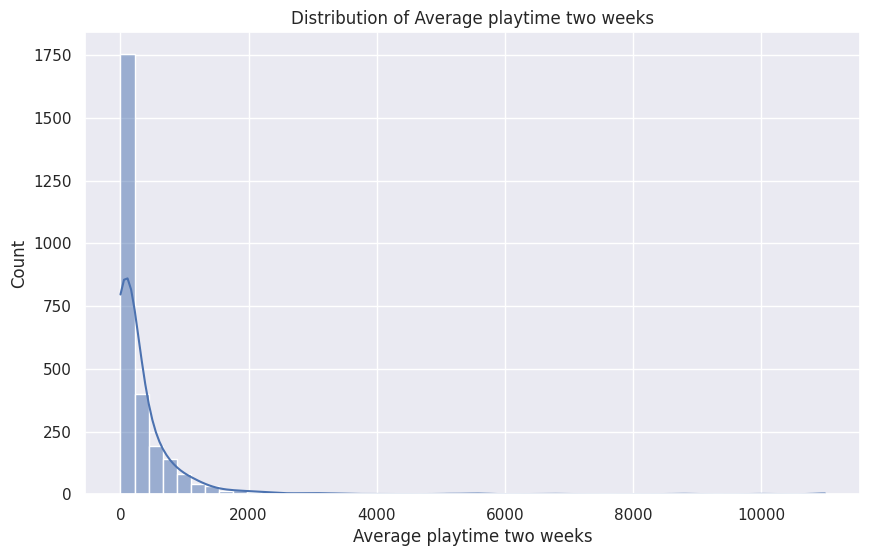

In [110]:
print(f"\nDistribution of {TARGET_COL}:")
print(reg_df[TARGET_COL].describe())
plt.figure(figsize=(10, 6))
sns.histplot(reg_df[TARGET_COL], bins=50, kde=True)
plt.title(f'Distribution of {TARGET_COL}')
plt.xlabel(TARGET_COL)
plt.ylabel('Count')
plt.show()

# Splitting Data into Train/Test/Split

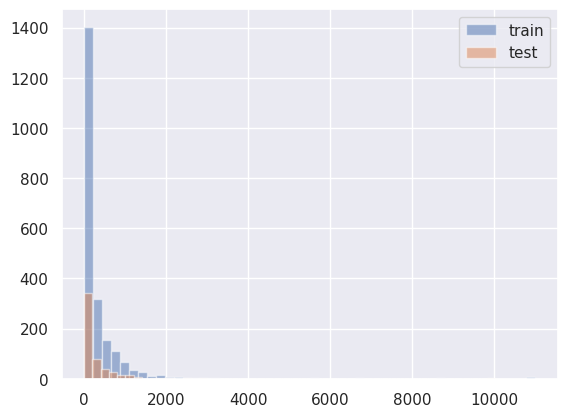

In [120]:
from sklearn.model_selection import train_test_split

# Create quantile bins (e.g., deciles)
reg_df["target_bin"] = pd.qcut(y, q=10, labels=False, duplicates="drop")

# train vs test
train_df, test_df = train_test_split(
    reg_df, test_size=0.2, stratify=reg_df["target_bin"], random_state=42
)

# Drop helper column
for d in [train_df, test_df]:
    d.drop(columns=["target_bin"], inplace=True)


plt.hist(train_df[TARGET_COL], bins=50, alpha=0.5, label='train')
plt.hist(test_df[TARGET_COL], bins=50, alpha=0.5, label='test')
plt.legend()
plt.show()

X_train = train_df.drop(columns=TARGET_COL)
y_train = train_df[TARGET_COL]

X_test = test_df.drop(columns=TARGET_COL)
y_test = test_df[TARGET_COL]

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

By training on log1p(y) skew is reduced so that the model treats large and small playtimes more evenly and feature importance reflects factors affecting typical behavior rather than extreme outliers

# Importing Performance Metrics

In [117]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    average_precision_score,
    precision_recall_curve,
    mean_squared_error,
    r2_score,
    mean_absolute_error
)

# Dataframe to compare performance metrics on classifier models
regression_performance_data = {'Metric': ['MSE',
                                          'RMSE',
                                          'R2',
                                          'MAE']}

reg_performance = pd.DataFrame(regression_performance_data)
reg_performance = reg_performance.set_index('Metric')

print("log1p min: ", np.log1p(reg_df[TARGET_COL]).min())
print("log1p max: ", np.log1p(reg_df[TARGET_COL]).max())

""
Metric
MSE
RMSE
R2
MAE


# Random Forests

## Basic

In [ ]:
import optuna
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold, cross_val_predict

# check model fit based on cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

def randomForestObjective(trial):
    # paramaters to hypertune
    n_estimators = trial.suggest_int("n_estimators", 50, 500)
    max_depth = trial.suggest_int("max_depth", 1, 45)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 10)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", None])
    bootstrap = trial.suggest_categorical("bootstrap", [True, False])
    criterion = trial.suggest_categorical("criterion", ["squared_error", "absolute_error", "poisson"])


    # random forest regressor
    regr= RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42,
        max_features=max_features,
        bootstrap=bootstrap,
        criterion=criterion,
        n_jobs=-1
    )

    # mse is the best metric for such an imbalanced dataset
    mse_score  = cross_val_score(regr, X_train, y_train, cv=kf, scoring="neg_mean_squared_error").mean()

    return mse_score

# Utilize Optuna to obtain the best parameters
study_rf = optuna.create_study(direction="maximize")
study_rf.optimize(randomForestObjective, n_trials=15) #increase if you have time
best_params_rf = study_rf.best_params

# print best parameters
print("Best hyperparameters:", best_params_rf)
print("Best negative MSE:", study_rf.best_value)

[I 2025-11-23 18:54:02,684] A new study created in memory with name: no-name-bcdabf6e-5e50-443c-923e-0b079def6917
[I 2025-11-23 18:55:10,207] Trial 0 finished with value: -834466.1001065077 and parameters: {'n_estimators': 161, 'max_depth': 36, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'bootstrap': False, 'criterion': 'absolute_error'}. Best is trial 0 with value: -834466.1001065077.
[I 2025-11-23 18:55:13,561] Trial 1 finished with value: -817512.7401513614 and parameters: {'n_estimators': 282, 'max_depth': 44, 'min_samples_split': 7, 'min_samples_leaf': 4, 'max_features': 'log2', 'bootstrap': False, 'criterion': 'squared_error'}. Best is trial 1 with value: -817512.7401513614.
[I 2025-11-23 18:56:05,482] Trial 2 finished with value: -1042179.6554105558 and parameters: {'n_estimators': 428, 'max_depth': 38, 'min_samples_split': 20, 'min_samples_leaf': 4, 'max_features': None, 'bootstrap': False, 'criterion': 'poisson'}. Best is trial 1 with value: -817512

In [ ]:
# refit model based on best parameters
regr_rf = RandomForestRegressor(
    **best_params_rf,
    random_state=42,
    n_jobs=-1
)

y_train_pred = cross_val_predict(
    regr_rf,
    X_train,
    y_train,
    cv=kf
)

regr_rf.fit(X_train, y_train_log)

# Evaluate training data
print("\nTRAIN METRICS:")
print("MSE:", mean_squared_error(y_train_log, y_train_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_train_log, y_train_pred)))
print("R2:", r2_score(y_train_log, y_train_pred))
print("MAE:", mean_absolute_error(y_train_log, y_train_pred))

# Evaluate test data
y_test_pred = regr_rf.predict(X_test)

print("\nTEST METRICS:")
print("MSE:", mean_squared_error(y_test_log, y_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test_log, y_test_pred)))
print("R2:", r2_score(y_test_log, y_test_pred))
print("MAE:", mean_absolute_error(y_test_log, y_test_pred))

# Store performance for comparison later
reg_performance['Random Forest'] = [
    mean_squared_error(y_test_log, y_test_pred),
    np.sqrt(mean_squared_error(y_test_log, y_test_pred)),
    r2_score(y_test_log, y_test_pred),
    mean_absolute_error(y_test_log, y_test_pred)
]

# Save predictions for plotting later if needed
y_test_pred_rf = y_test_pred

In [ ]:
#plot
plt.figure(figsize=(12, 7))
plt.scatter(y_test, y_test_pred, alpha=0.3)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel("actual playtime")
plt.ylabel("predicted playtime")
plt.title("actual vs predicted playtime")
plt.show()

#XGBoost

## Basic

In [138]:
from xgboost import XGBRegressor

def xgboostObjective(trial):
    # paramaters to hypertune
    eval_metric = trial.suggest_categorical("eval_metric", ["rmse", "mae", "rmsle"])
    n_estimators = trial.suggest_int("n_estimators", 50, 500)
    max_depth = trial.suggest_int("max_depth", 3, 10)
    min_child_weight = trial.suggest_int("min_child_weight", 1, 10)
    gamma = trial.suggest_float("gamma", 0, 5)
    max_delta_step = trial.suggest_int("max_delta_step", 0, 10)
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.3)
    subsample = trial.suggest_float("subsample", 0.1, 1)
    colsample_bytree = trial.suggest_float("colsample_bytree", 0.5, 1)
    reg_alpha = trial.suggest_float("reg_alpha", 0, 1)
    reg_lambda = trial.suggest_float("reg_lambda", 0, 10)

    # xgboost classifier
    reg_xgb = XGBRegressor(
        objective="reg:squarederror",
        eval_metric=eval_metric,
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_child_weight=min_child_weight,
        gamma=gamma,
        max_delta_step=max_delta_step,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        reg_alpha=reg_alpha,
        reg_lambda=reg_lambda,
        random_state=42,
        n_jobs=-1,
    )

    # MSE is the best metric for such an imbalanced dataset
    mse_score = cross_val_score(reg_xgb, X_train, y_train_log, cv=kf, scoring="neg_mean_squared_error").mean()

    return mse_score

# Utilize Optuna to obtain the best parameters
study_xgb = optuna.create_study(direction="maximize")
study_xgb.optimize(xgboostObjective, n_trials=15) #increase if have time
best_params_xgb = study_xgb.best_params

# print best parameters
print("Best hyperparameters:", best_params_xgb)
print("Best negative MSE:", study_xgb.best_value)

[I 2025-11-23 18:44:23,590] A new study created in memory with name: no-name-f873c092-0a1d-499b-970e-254c8fe66615
[I 2025-11-23 18:44:25,987] Trial 0 finished with value: -2.1262433925341844 and parameters: {'eval_metric': 'rmse', 'n_estimators': 422, 'max_depth': 10, 'min_child_weight': 1, 'gamma': 2.9455211281757174, 'max_delta_step': 9, 'learning_rate': 0.1370844942448503, 'subsample': 0.42535664454914934, 'colsample_bytree': 0.6747503944684342, 'reg_alpha': 0.8186949654133445, 'reg_lambda': 1.0060831162009554}. Best is trial 0 with value: -2.1262433925341844.
[I 2025-11-23 18:44:27,213] Trial 1 finished with value: -2.083435936369367 and parameters: {'eval_metric': 'rmse', 'n_estimators': 214, 'max_depth': 4, 'min_child_weight': 4, 'gamma': 2.6881758192220886, 'max_delta_step': 10, 'learning_rate': 0.24818856364624428, 'subsample': 0.7622176078622086, 'colsample_bytree': 0.5924864142668513, 'reg_alpha': 0.7331547155934999, 'reg_lambda': 4.711848512551946}. Best is trial 1 with valu

Best hyperparameters: {'eval_metric': 'mae', 'n_estimators': 98, 'max_depth': 6, 'min_child_weight': 9, 'gamma': 1.4494317540786965, 'max_delta_step': 7, 'learning_rate': 0.03354822024531641, 'subsample': 0.747968054887701, 'colsample_bytree': 0.8995378337945927, 'reg_alpha': 0.011460456385420925, 'reg_lambda': 4.084116597208441}
Best negative MSE: -1.8994033722254677


In [140]:
# refit model based on best parameters
regr_xgb = XGBRegressor(
        objective="reg:squarederror",
        **best_params_xgb,
        random_state=42,
        n_jobs=-1
)

y_train_pred = cross_val_predict(
    regr_xgb,
    X_train,
    y_train_log,
    cv=kf
)

regr_xgb.fit(X_train, y_train_log)

# Evaluate training data
print("\nTRAIN METRICS:")
print("MSE:", mean_squared_error(y_train_log, y_train_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_train_log, y_train_pred)))
print("R2:", r2_score(y_train_log, y_train_pred))
print("MAE:", mean_absolute_error(y_train_log, y_train_pred))

# Evaluate test data
y_test_pred = regr_xgb.predict(X_test)

print("\nTEST METRICS:")
print("MSE:", mean_squared_error(y_test_log, y_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test_log, y_test_pred)))
print("R2:", r2_score(y_test_log, y_test_pred))
print("MAE:", mean_absolute_error(y_test_log, y_test_pred))

# Store performance for comparison later
reg_performance['Random Forest'] = [
    mean_squared_error(y_test_log, y_test_pred),
    np.sqrt(mean_squared_error(y_test_log, y_test_pred)),
    r2_score(y_test_log, y_test_pred),
    mean_absolute_error(y_test_log, y_test_pred)
]

# Save predictions for plotting later if needed
y_test_pred_xgb = y_test_pred


TRAIN METRICS:
MSE: 1.89934300035817
RMSE: 1.3781665357851967
R2: 0.3411688356760062
MAE: 0.9679076544436757

TEST METRICS:
MSE: 2.072450171222269
RMSE: 1.4396006985349337
R2: 0.2791087818647916
MAE: 1.0074397925644631


In [141]:
#identify important features
print("important features:")
feature_importances = pd.Series(regr_xgb.feature_importances_, index=X.columns)
print(feature_importances.nlargest(30))

important features:
Peak CCU                     0.061603
Price                        0.038669
Remote Play on Tablet        0.035442
nudity                       0.025298
lyrics                       0.023243
Racing                       0.021547
Video Production             0.020696
blood_and_gore               0.018679
cartoon_violence             0.018172
Co-op                        0.017815
Short                        0.017790
Steam Turn Notifications     0.017459
Casual                       0.017360
Mac                          0.017334
Online Co-op                 0.016797
Linux                        0.016430
release_year                 0.016410
Tutorial                     0.016187
Metacritic score             0.015980
midpoint_estimated_owners    0.015931
esrb_age                     0.015866
Online PvP                   0.015700
Recommendations              0.015623
Adventure                    0.014944
Stats                        0.014762
Strategy                     0

# Performance Measure Comparison

In [123]:
reg_performance.head(7)

,Random Forest
Metric,
MSE,691979.308181
RMSE,831.852937
R2,0.036579
MAE,334.790845


In [127]:
import shap

explainer = shap.TreeExplainer(regr_xgb)
shap_values = explainer(X_test)

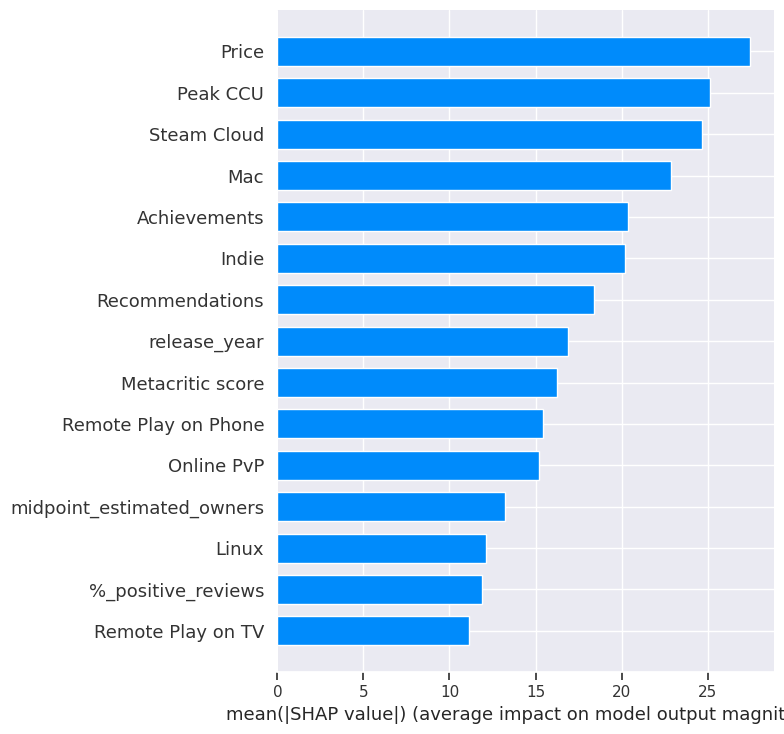

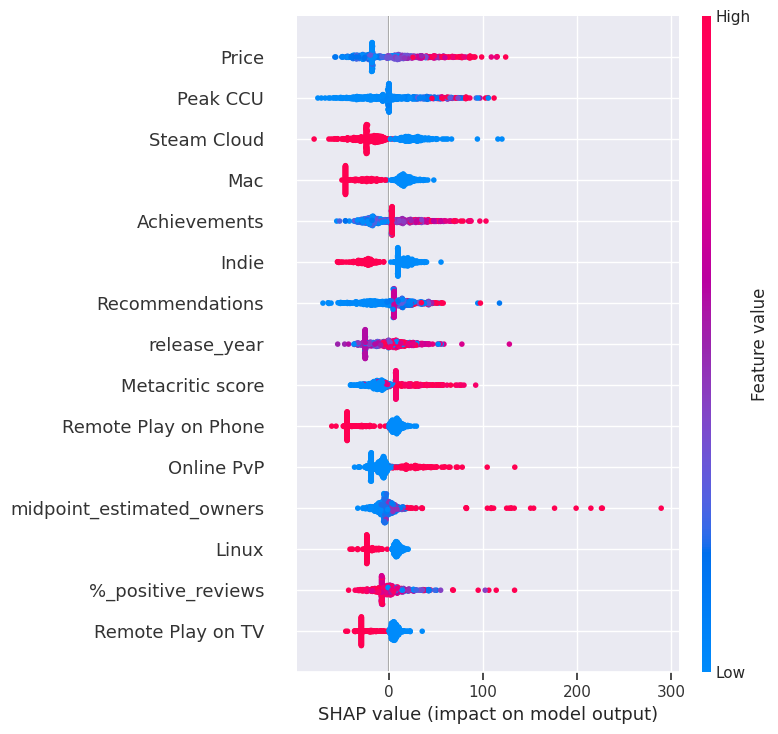

In [128]:
shap.summary_plot(
    shap_values,
    X_test,
    max_display=15
)

# **OTHER**

In [ ]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

#drop the target column from features
x = steam.drop(columns=target_column, errors='ignore')
y = steam[target_column]


#handle any remaining non-numeric columns that slipped through convert to numeric if possible, otherwise drop
for col in x.columns:
    if x[col].dtype == 'object':
        try:
            x[col] = pd.to_numeric(x[col], errors='coerce')
        except:            x = x.drop(columns=[col])

#drop rows with NaN values
initial_rows = x.shape[0]
combined = pd.concat([x, y], axis=1).dropna(subset=[target_column])
x = combined.drop(columns=[target_column])
y = combined[target_column]

if initial_rows > x.shape[0]:
    print(f"dropped {initial_rows - x.shape[0]} rows due to NaN in target variable.\n")
x = x.fillna(x.mean())

#split data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(f"shape of training data: X_train={x_train.shape}, y_train={y_train.shape}")
print(f"shape of testing data: X_test={x_test.shape}, y_test={y_test.shape}\n")

# Initialize and train the XGBoost Regressor model
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb_model.fit(x_train, y_train)

# Make predictions on the test set
y_pred = xgb_model.predict(x_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"xgboost model performance")
print(f"rmse {rmse:.2f}")
print(f"r-squared: {r2:.2f}")
print(f"mae: {mae:.2f}\n")

#identify important features
print("important features:")
feature_importances = pd.Series(xgb_model.feature_importances_, index=x.columns)
print(feature_importances.nlargest(10))

#plot
plt.figure(figsize=(12, 7))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel("actual playtime")
plt.ylabel("predicted playtime")
plt.title("actual vs predicted playtime")
plt.show()

In [ ]:
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.7, 0.9],
    'colsample_bytree': [0.7, 0.9]
}

In [ ]:
from sklearn.model_selection import GridSearchCV

#xgb regressor
xgb = XGBRegressor(random_state=42, n_jobs=-1)

#grid search
grid_search = GridSearchCV(estimator=xgb,
                           param_grid=param_grid,
                           scoring='neg_mean_squared_error',
                           cv=3,
                           verbose=2,
                           n_jobs=-1)

In [ ]:
#fit grid search
grid_search.fit(x_train, y_train)

In [ ]:
print("best parameters:", grid_search.best_params_)
print("best rmse:", np.sqrt(-grid_search.best_score_))

In [ ]:
best_xgb_model = grid_search.best_estimator_

#make prediction
y_pred_tuned = best_xgb_model.predict(x_test)

#evaluate model
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_tuned = r2_score(y_test, y_pred_tuned)
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)

print(f"xgb performance")
print(f"rmse: {rmse_tuned:.2f}")
print(f"r-squared: {r2_tuned:.2f}")
print(f"mae: {mae_tuned:.2f}")

#plot predictions vs actual for tuned model
plt.figure(figsize=(12, 7))
plt.scatter(y_test, y_pred_tuned, alpha=0.3)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel("actual playtime")
plt.ylabel("predicted playtime")
plt.title("actual vs predicted playtime")
plt.show()